# Synchrony and metastability analysis

This notebook reproduces the retained synchrony, metastability and QIDS analyses from the report. It displays results only; it does not write tables or figures to disk.


In [44]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm

from IPython.display import display
from matplotlib.lines import Line2D
from scipy import stats
from scipy.signal import hilbert
from statsmodels.nonparametric.smoothers_lowess import lowess
from statsmodels.stats.multitest import multipletests


## Data and network definitions


In [ ]:
ROOT = #INSERT ROOT
INPUT_FILE = # ROOT / INSERT PATH TO PARCELLATED TIME SERIES
LABEL_FILE = # ROOT / INSERT PATH TO NETWORK LABEL FILE

TR = 1.25
RANDOM_SEED = 50
N_PERMUTATIONS = 100_000

metadata_columns = [
    "scan_ids", "subjects", "sessions", "timepoints", "treatment",
    "qids_pre", "qids_post", "qids_reduction", "qids_percent_reduction",
    "responder_50pct", "achieved_remission", "response_status", "remission_status",
]

with np.load(INPUT_FILE, allow_pickle=False) as data:
    timeseries = data["timeseries"].astype(np.float32)
    scan_info = pd.DataFrame({name: data[name].copy() for name in metadata_columns})

n_scans, n_timepoints, n_parcels = timeseries.shape


In [46]:
lines = [line.strip() for line in LABEL_FILE.read_text().splitlines() if line.strip()]
parcel_names = np.array(lines[::2][16:] + lines[::2][:16])

network_name_map = {
    "Vis": "Visual",
    "SomMot": "Somatomotor",
    "DorsAttn": "Dorsal attention",
    "SalVentAttn": "Salience / ventral attention",
    "Limbic": "Limbic",
    "Cont": "Control / frontoparietal",
    "Default": "Default mode",
}
NETWORK_ORDER = [
    "Visual", "Somatomotor", "Dorsal attention",
    "Salience / ventral attention", "Limbic",
    "Control / frontoparietal", "Default mode", "Subcortex",
]
NETWORK_SHORT_NAMES = ["VIS", "SM", "DAN", "SAL/VAN", "LIM", "FPCN", "DMN", "SUB"]

parcel_networks = np.array([
    network_name_map[name.split("_")[2]] if name.startswith("7Networks_") else "Subcortex"
    for name in parcel_names
])
network_indices = {
    network: np.flatnonzero(parcel_networks == network)
    for network in NETWORK_ORDER
}


## Synchrony and metastability


In [47]:
def extract_phase(scan):
    scan = scan.astype(float) - scan.mean(axis=0, keepdims=True)
    return np.angle(hilbert(scan, axis=0))


spatial_sets = {
    "Whole brain": np.arange(n_parcels),
    **{network: network_indices[network] for network in NETWORK_ORDER},
}

rows = []
for scan_index, scan in enumerate(timeseries):
    phase = extract_phase(scan)
    for spatial_set, indices in spatial_sets.items():
        synchrony = np.abs(np.exp(1j * phase[:, indices]).mean(axis=1))
        rows.append({
            **scan_info.iloc[scan_index].to_dict(),
            "spatial_set": spatial_set,
            "n_parcels": len(indices),
            "synchrony": synchrony.mean(),
            "metastability": synchrony.std(ddof=0),
        })

phase_dynamics = pd.DataFrame(rows)


### Example instantaneous phase-coherence matrix


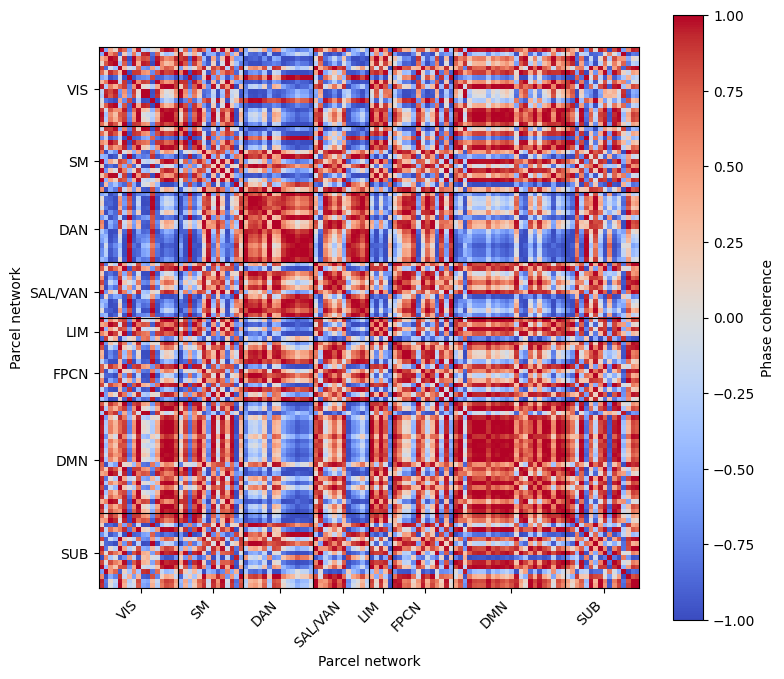

In [48]:
phase = extract_phase(timeseries[0])
phase_coherence = np.cos(phase[350, :, None] - phase[350, None, :])
parcel_order = np.concatenate([network_indices[network] for network in NETWORK_ORDER])
network_sizes = [len(network_indices[network]) for network in NETWORK_ORDER]
boundaries = np.cumsum(network_sizes)
centres = np.r_[0, boundaries[:-1]] + np.array(network_sizes) / 2
phase_coherence = phase_coherence[np.ix_(parcel_order, parcel_order)]

fig, ax = plt.subplots(figsize=(8, 7))
image = ax.imshow(phase_coherence, cmap="coolwarm", vmin=-1, vmax=1)
for boundary in boundaries[:-1]:
    ax.axhline(boundary - 0.5, color="black", linewidth=0.8)
    ax.axvline(boundary - 0.5, color="black", linewidth=0.8)
ax.set_xticks(centres, labels=NETWORK_SHORT_NAMES, rotation=45, ha="right")
ax.set_yticks(centres, labels=NETWORK_SHORT_NAMES)
ax.set_xlabel("Parcel network")
ax.set_ylabel("Parcel network")
fig.colorbar(image, ax=ax, label="Phase coherence")
fig.tight_layout()
plt.show()


### Pre–post changes and sign-flip inference


In [49]:
change_tables = []
for metric in ["synchrony", "metastability"]:
    paired = (
        phase_dynamics.pivot_table(
            index=["subjects", "treatment", "spatial_set"],
            columns="timepoints",
            values=metric,
            aggfunc="first",
        )
        .reindex(columns=["pre", "post"])
        .dropna()
        .reset_index()
    )
    paired["change"] = paired["post"] - paired["pre"]
    paired["metric"] = metric
    change_tables.append(paired)

phase_changes = pd.concat(change_tables, ignore_index=True)


In [50]:
def sign_flip_inference(changes, seed):
    changes = np.asarray(changes, dtype=float)
    n = len(changes)
    rng = np.random.default_rng(seed)
    signs = rng.choice([-1, 1], size=(N_PERMUTATIONS, n))
    signed_sums = signs @ changes
    sign_sums = signs.sum(axis=1)
    estimate = changes.mean()
    tolerance = 100 * np.finfo(float).eps * max(1, np.abs(changes).max())

    def p_value(null):
        observed = abs(estimate - null)
        permuted = np.abs((signed_sums - null * sign_sums) / n)
        return (np.count_nonzero(permuted >= observed - tolerance) + 1) / (N_PERMUTATIONS + 1)

    step = max(changes.std(ddof=1), np.ptp(changes), abs(estimate), 1e-6)
    bounds = []
    for direction in [-1, 1]:
        inside = estimate
        outside = estimate + direction * step
        while p_value(outside) >= 0.05:
            outside = estimate + 2 * (outside - estimate)
        for _ in range(50):
            midpoint = (inside + outside) / 2
            if p_value(midpoint) >= 0.05:
                inside = midpoint
            else:
                outside = midpoint
        bounds.append(inside)

    return {
        "n": n,
        "mean_change": estimate,
        "ci_low": bounds[0],
        "ci_high": bounds[1],
        "p_raw": p_value(0),
        "exact_test": False,
    }


treatment_order = ["escitalopram", "psilocybin"]
spatial_order = ["Whole brain", *NETWORK_ORDER]
rows = []
for metric_index, metric in enumerate(["synchrony", "metastability"]):
    for treatment_index, treatment in enumerate(treatment_order):
        for region_index, spatial_set in enumerate(spatial_order):
            changes = phase_changes.loc[
                (phase_changes["metric"] == metric)
                & (phase_changes["treatment"] == treatment)
                & (phase_changes["spatial_set"] == spatial_set),
                "change",
            ].to_numpy()
            rows.append({
                "metric": metric,
                "treatment": treatment,
                "spatial_set": spatial_set,
                **sign_flip_inference(
                    changes,
                    RANDOM_SEED + 1000 * metric_index + 100 * treatment_index + region_index,
                ),
            })

phase_pre_post_tests = pd.DataFrame(rows)
phase_pre_post_tests["p_fdr"] = np.nan
network_rows = phase_pre_post_tests["spatial_set"] != "Whole brain"
for indices in phase_pre_post_tests.loc[network_rows].groupby(["metric", "treatment"]).groups.values():
    phase_pre_post_tests.loc[indices, "p_fdr"] = multipletests(
        phase_pre_post_tests.loc[indices, "p_raw"], method="fdr_bh"
    )[1]


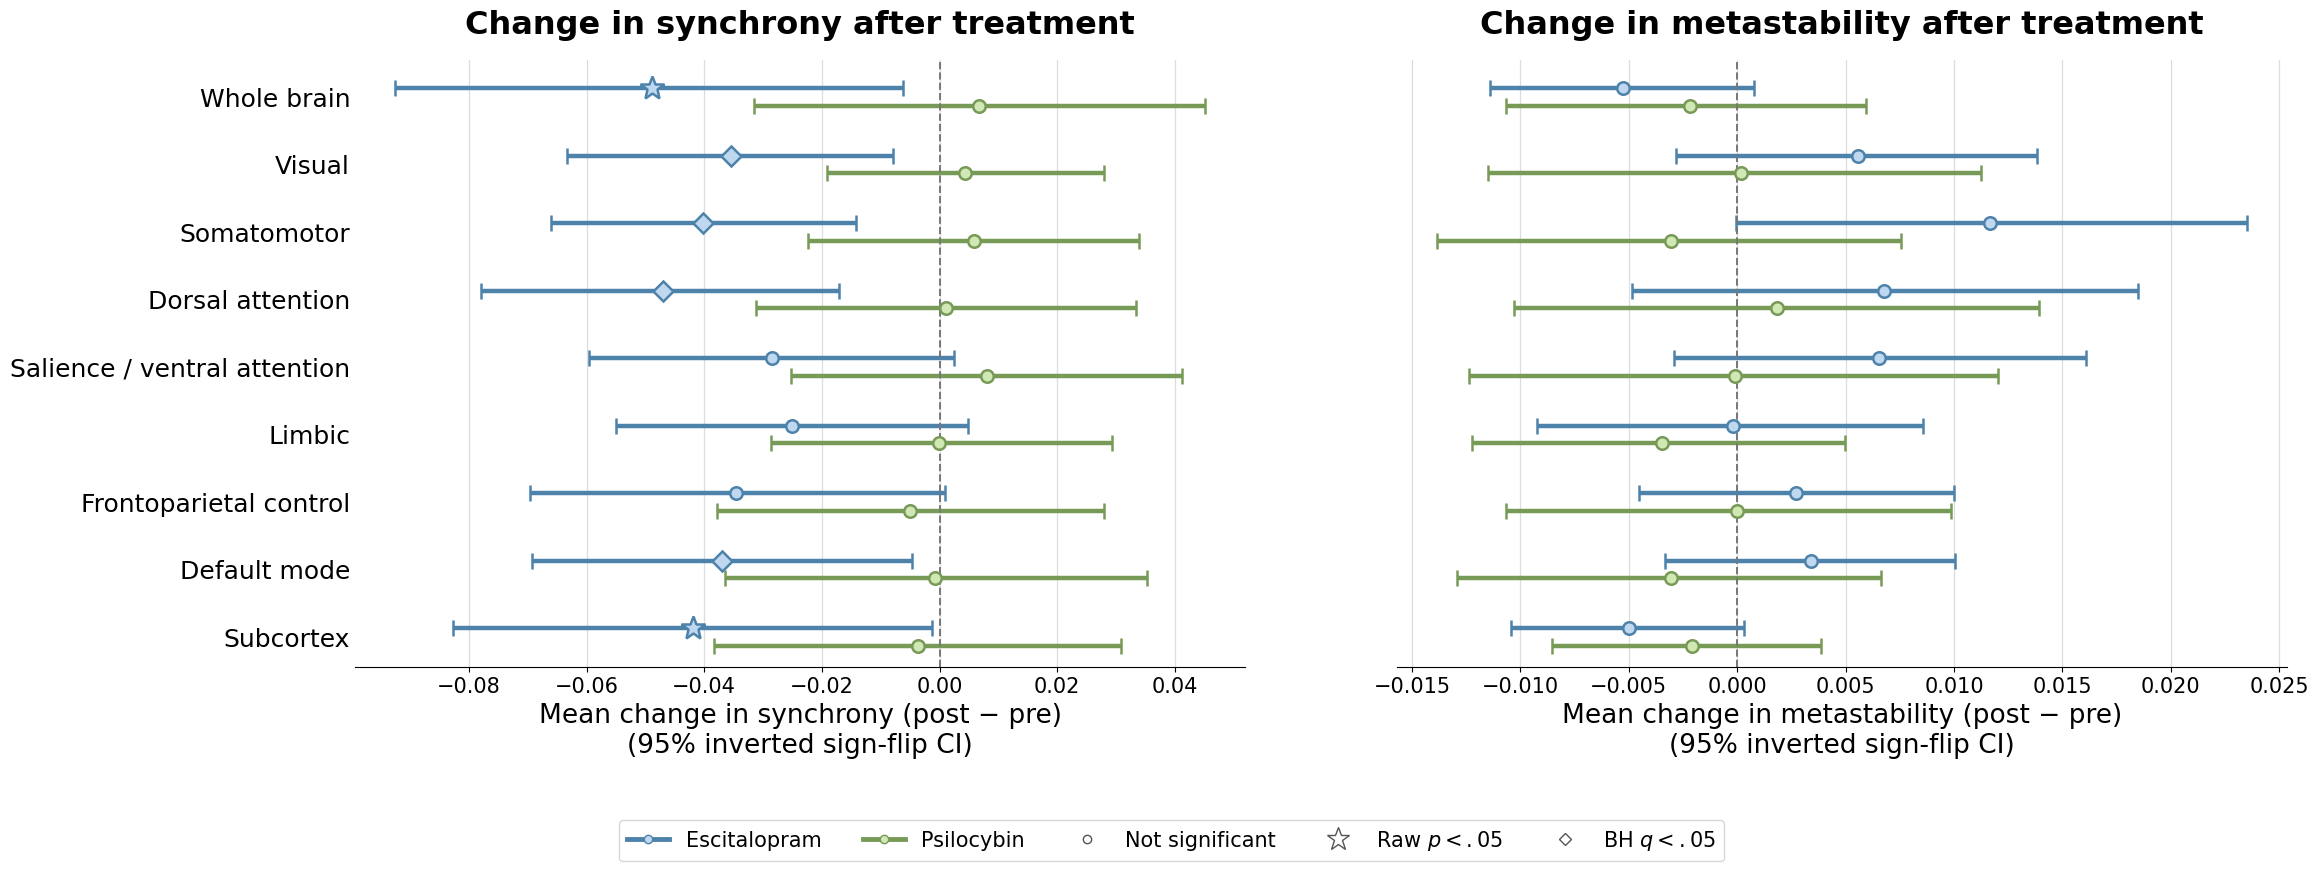

,metric,treatment,spatial_set,n,mean_change,ci_low,ci_high,p_raw,p_fdr,exact_test
0,metastability,escitalopram,Control / frontoparietal,21,0.0027,-0.0045,0.0100,0.4532,0.5180,False
1,metastability,escitalopram,Default mode,21,0.0034,-0.0033,0.0101,0.3031,0.4041,False
2,metastability,escitalopram,Dorsal attention,21,0.0068,-0.0049,0.0185,0.2461,0.3937,False
3,metastability,escitalopram,Limbic,21,-0.0002,-0.0092,0.0086,0.9700,0.9700,False
4,metastability,escitalopram,Salience / ventral attention,21,0.0066,-0.0029,0.0161,0.1624,0.3551,False
5,metastability,escitalopram,Somatomotor,21,0.0117,-0.0001,0.0235,0.0509,0.2602,False
6,metastability,escitalopram,Subcortex,21,-0.0050,-0.0104,0.0003,0.0650,0.2602,False
7,metastability,escitalopram,Visual,21,0.0056,-0.0028,0.0138,0.1775,0.3551,False
8,metastability,escitalopram,Whole brain,21,-0.0053,-0.0114,0.0008,0.0852,—,False
9,metastability,psilocybin,Control / frontoparietal,22,-0.0000,-0.0107,0.0099,0.9958,0.9958,False


In [51]:
treatment_style = {
    "escitalopram": {"label": "Escitalopram", "fill": "#BFD8F0", "edge": "#4D82AA"},
    "psilocybin": {"label": "Psilocybin", "fill": "#CFE8B4", "edge": "#789A57"},
}
spatial_display = {"Control / frontoparietal": "Frontoparietal control"}
y_positions = np.arange(len(spatial_order))

fig, axes = plt.subplots(1, 2, figsize=(23, 9.2), sharey=True, facecolor="white")
for ax, metric, title in zip(
    axes,
    ["synchrony", "metastability"],
    ["Change in synchrony after treatment", "Change in metastability after treatment"],
):
    for treatment, offset in zip(treatment_order, [-0.13, 0.13]):
        style = treatment_style[treatment]
        for region_index, spatial_set in enumerate(spatial_order):
            result = phase_pre_post_tests.loc[
                (phase_pre_post_tests["metric"] == metric)
                & (phase_pre_post_tests["treatment"] == treatment)
                & (phase_pre_post_tests["spatial_set"] == spatial_set)
            ].iloc[0]
            if spatial_set == "Whole brain":
                marker, size = (("*", 18) if result["p_raw"] < 0.05 else ("o", 9))
            elif result["p_fdr"] < 0.05:
                marker, size = "D", 10
            elif result["p_raw"] < 0.05:
                marker, size = "*", 18
            else:
                marker, size = "o", 9

            ax.errorbar(
                result["mean_change"],
                region_index + offset,
                xerr=[[result["mean_change"] - result["ci_low"]],
                      [result["ci_high"] - result["mean_change"]]],
                fmt=marker,
                markersize=size,
                markerfacecolor=style["fill"],
                markeredgecolor=style["edge"],
                markeredgewidth=1.8,
                ecolor=style["edge"],
                elinewidth=3.2,
                capsize=6,
            )

    ax.axvline(0, color="#777777", linestyle="--", linewidth=1.4)
    ax.set_yticks(y_positions, labels=[spatial_display.get(x, x) for x in spatial_order])
    ax.set_ylim(len(spatial_order) - 0.55, -0.55)
    ax.set_xlabel(f"Mean change in {metric} (post − pre)\n(95% inverted sign-flip CI)", fontsize=19)
    ax.set_title(title, fontsize=23, fontweight="bold", pad=19)
    ax.grid(axis="x", color="#DDDDDD", linewidth=0.9)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.tick_params(axis="y", length=0, labelsize=18)
    ax.tick_params(axis="x", labelsize=15)

fig.legend(
    handles=[
        Line2D([0], [0], marker="o", color="#4D82AA", markerfacecolor="#BFD8F0", linewidth=3.5, label="Escitalopram"),
        Line2D([0], [0], marker="o", color="#789A57", markerfacecolor="#CFE8B4", linewidth=3.5, label="Psilocybin"),
        Line2D([0], [0], marker="o", color="none", markeredgecolor="#555555", label="Not significant"),
        Line2D([0], [0], marker="*", color="none", markeredgecolor="#555555", markersize=17, label=r"Raw $p < .05$"),
        Line2D([0], [0], marker="D", color="none", markeredgecolor="#555555", label=r"BH $q < .05$"),
    ],
    loc="lower center", bbox_to_anchor=(0.5, 0.018), ncol=5, fontsize=15,
)
fig.subplots_adjust(left=0.145, right=0.985, top=0.90, bottom=0.24, wspace=0.17)
plt.show()

display(
    phase_pre_post_tests[
        ["metric", "treatment", "spatial_set", "n", "mean_change", "ci_low", "ci_high", "p_raw", "p_fdr", "exact_test"]
    ]
    .sort_values(["metric", "treatment", "spatial_set"])
    .reset_index(drop=True)
    .style.format({
        "mean_change": "{:.4f}", "ci_low": "{:.4f}", "ci_high": "{:.4f}",
        "p_raw": "{:.4f}", "p_fdr": "{:.4f}",
    }, na_rep="—")
)


## Baseline-adjusted QIDS-change regressions


In [52]:
clinical_data = scan_info[
    ["subjects", "treatment", "qids_pre", "qids_post"]
].drop_duplicates(["subjects", "treatment"]).copy()
clinical_data["qids_change"] = clinical_data["qids_post"] - clinical_data["qids_pre"]

phase_qids_regression_data = (
    phase_changes.merge(clinical_data, on=["subjects", "treatment"], validate="many_to_one")
    .rename(columns={"pre": "brain_pre", "post": "brain_post", "change": "brain_change"})
)


In [53]:
def fit_qids_regression(data):
    model_data = data[
        ["subjects", "qids_pre", "qids_change", "brain_change"]
    ].dropna().reset_index(drop=True)
    y = model_data["qids_change"].astype(float)
    X = sm.add_constant(model_data[["qids_pre", "brain_change"]].astype(float))
    ordinary = sm.OLS(y, X).fit()
    robust = sm.OLS(y, X).fit(cov_type="HC3", use_t=True)
    reduced = sm.OLS(y, sm.add_constant(model_data[["qids_pre"]].astype(float))).fit()

    ci = robust.conf_int().loc["brain_change"]
    factor = model_data["brain_change"].std(ddof=1) / model_data["qids_change"].std(ddof=1)
    influence = ordinary.get_influence()
    cooks_distance = influence.cooks_distance[0]

    return {
        "n": len(model_data),
        "intercept": robust.params["const"],
        "beta_qids_pre": robust.params["qids_pre"],
        "p_qids_pre": robust.pvalues["qids_pre"],
        "mean_qids_pre": model_data["qids_pre"].mean(),
        "beta_brain_change": robust.params["brain_change"],
        "brain_change_hc3_se": robust.bse["brain_change"],
        "brain_change_ci_low": ci.iloc[0],
        "brain_change_ci_high": ci.iloc[1],
        "standardised_beta": robust.params["brain_change"] * factor,
        "standardised_ci_low": ci.iloc[0] * factor,
        "standardised_ci_high": ci.iloc[1] * factor,
        "partial_r2": (np.sum(reduced.resid**2) - np.sum(ordinary.resid**2)) / np.sum(reduced.resid**2),
        "adjusted_r2": ordinary.rsquared_adj,
        "p_raw": robust.pvalues["brain_change"],
        "max_cooks_subject": model_data.loc[np.argmax(cooks_distance), "subjects"],
        "max_cooks_d": cooks_distance.max(),
        "cooks_threshold": 4 / len(model_data),
        "n_cooks_above_threshold": np.sum(cooks_distance > 4 / len(model_data)),
    }, ordinary, model_data


regression_rows = []
regression_models = {}
for treatment in treatment_order:
    for metric in ["synchrony", "metastability"]:
        for spatial_set in spatial_order:
            subset = phase_qids_regression_data.loc[
                (phase_qids_regression_data["treatment"] == treatment)
                & (phase_qids_regression_data["metric"] == metric)
                & (phase_qids_regression_data["spatial_set"] == spatial_set)
            ]
            result, model, model_data = fit_qids_regression(subset)
            regression_rows.append({
                "treatment": treatment,
                "metric": metric,
                "spatial_set": spatial_set,
                **result,
            })
            regression_models[(treatment, metric, spatial_set)] = (model, model_data)

phase_qids_regressions = pd.DataFrame(regression_rows)
phase_qids_regressions["p_fdr"] = np.nan
network_rows = phase_qids_regressions["spatial_set"] != "Whole brain"
for indices in phase_qids_regressions.loc[network_rows].groupby(["treatment", "metric"]).groups.values():
    phase_qids_regressions.loc[indices, "p_fdr"] = multipletests(
        phase_qids_regressions.loc[indices, "p_raw"], method="fdr_bh"
    )[1]


### Regression coefficients


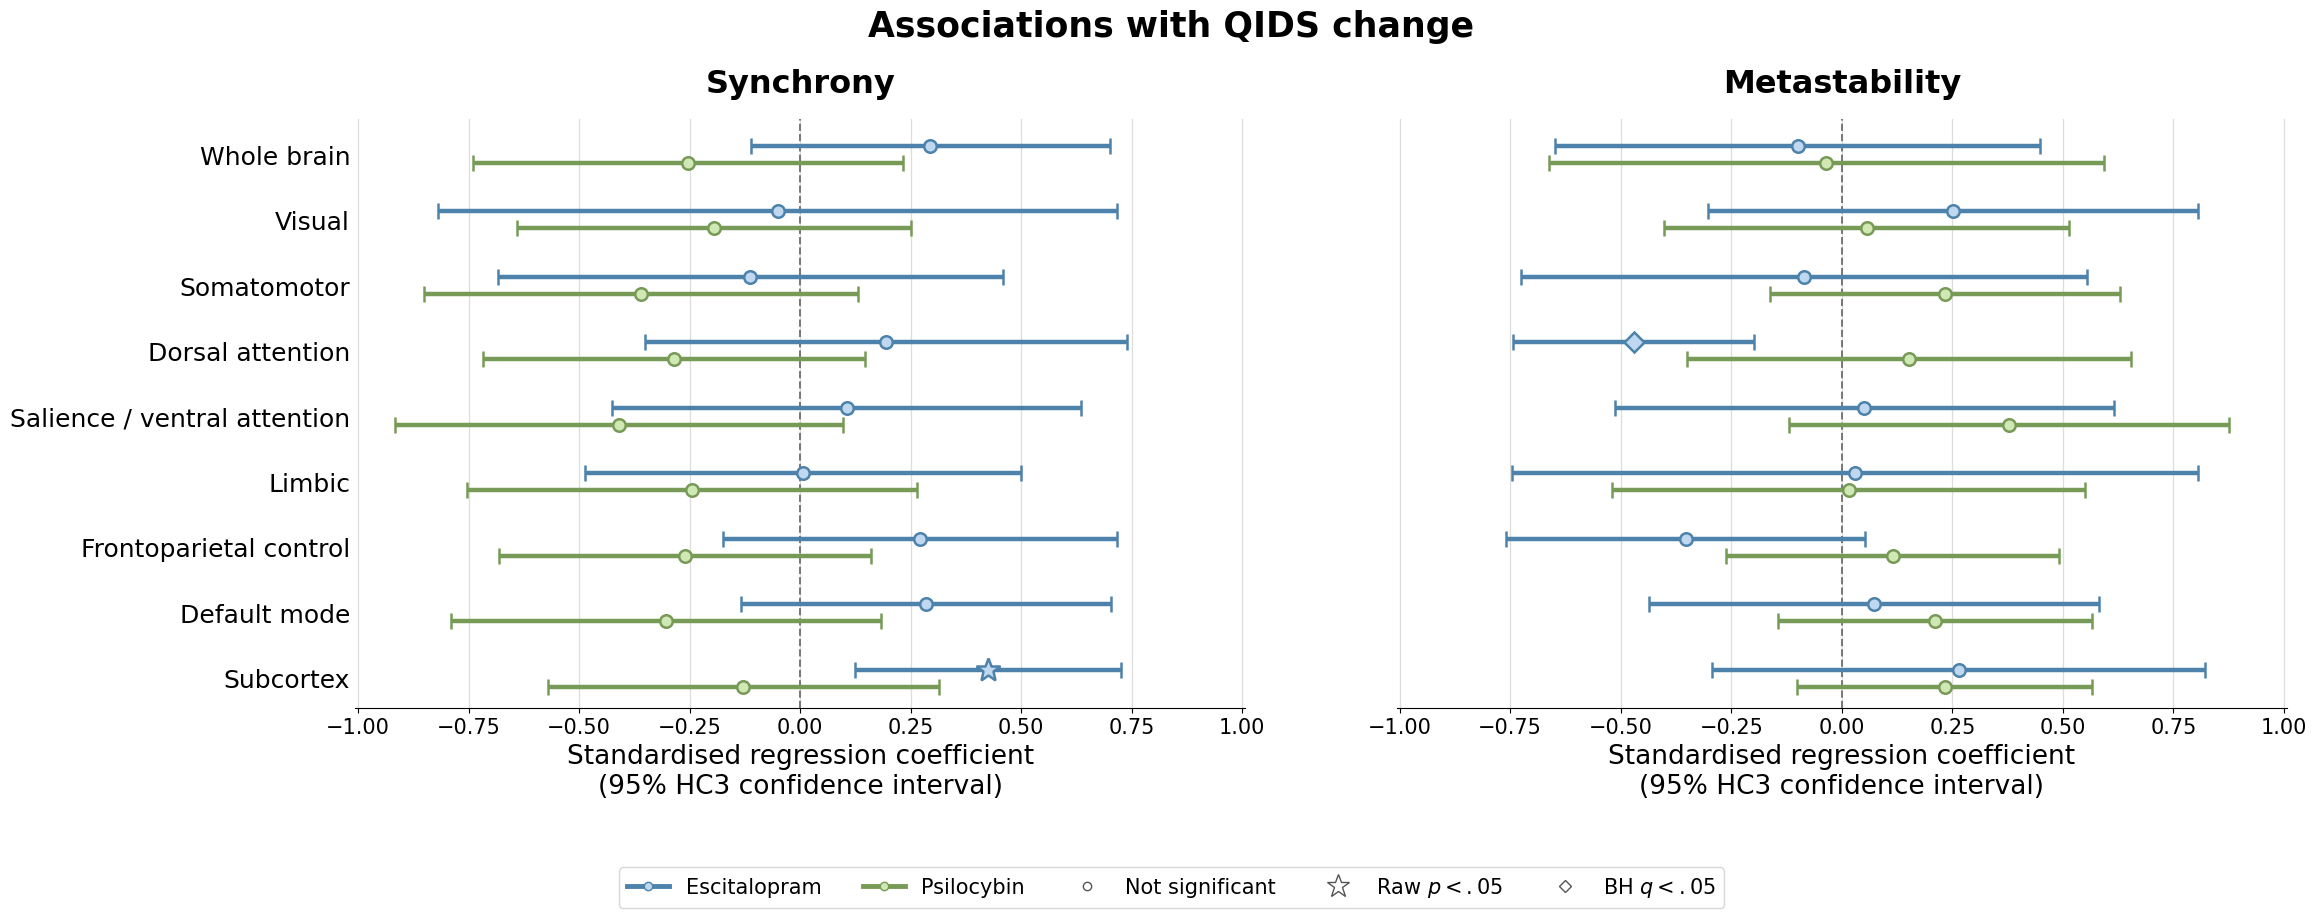

In [54]:
coefficient_limit = 1.10 * np.abs(
    phase_qids_regressions[["standardised_ci_low", "standardised_ci_high"]].to_numpy()
).max()
y_positions = np.arange(len(spatial_order))

fig, axes = plt.subplots(1, 2, figsize=(23, 9.5), sharex=True, sharey=True, facecolor="white")
for ax, metric, title in zip(axes, ["synchrony", "metastability"], ["Synchrony", "Metastability"]):
    ax.axvline(0, color="#777777", linestyle="--", linewidth=1.4)
    for treatment, offset in zip(treatment_order, [-0.13, 0.13]):
        style = treatment_style[treatment]
        for region_index, spatial_set in enumerate(spatial_order):
            result = phase_qids_regressions.loc[
                (phase_qids_regressions["metric"] == metric)
                & (phase_qids_regressions["treatment"] == treatment)
                & (phase_qids_regressions["spatial_set"] == spatial_set)
            ].iloc[0]
            if spatial_set == "Whole brain":
                marker, size = (("*", 18) if result["p_raw"] < 0.05 else ("o", 9))
            elif result["p_fdr"] < 0.05:
                marker, size = "D", 10
            elif result["p_raw"] < 0.05:
                marker, size = "*", 18
            else:
                marker, size = "o", 9
            ax.errorbar(
                result["standardised_beta"],
                region_index + offset,
                xerr=[[result["standardised_beta"] - result["standardised_ci_low"]],
                      [result["standardised_ci_high"] - result["standardised_beta"]]],
                fmt=marker,
                markersize=size,
                markerfacecolor=style["fill"],
                markeredgecolor=style["edge"],
                markeredgewidth=1.8,
                ecolor=style["edge"],
                elinewidth=3.2,
                capsize=6,
            )

    ax.set_yticks(y_positions, labels=[spatial_display.get(x, x) for x in spatial_order])
    ax.set_ylim(len(spatial_order) - 0.55, -0.55)
    ax.set_xlim(-coefficient_limit, coefficient_limit)
    ax.set_xlabel("Standardised regression coefficient\n(95% HC3 confidence interval)", fontsize=19)
    ax.set_title(title, fontsize=23, fontweight="bold", pad=19)
    ax.grid(axis="x", color="#DDDDDD", linewidth=0.9)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.tick_params(axis="y", length=0, labelsize=18)
    ax.tick_params(axis="x", labelsize=15)

fig.legend(
    handles=[
        Line2D([0], [0], marker="o", color="#4D82AA", markerfacecolor="#BFD8F0", linewidth=3.5, label="Escitalopram"),
        Line2D([0], [0], marker="o", color="#789A57", markerfacecolor="#CFE8B4", linewidth=3.5, label="Psilocybin"),
        Line2D([0], [0], marker="o", color="none", markeredgecolor="#555555", label="Not significant"),
        Line2D([0], [0], marker="*", color="none", markeredgecolor="#555555", markersize=17, label=r"Raw $p < .05$"),
        Line2D([0], [0], marker="D", color="none", markeredgecolor="#555555", label=r"BH $q < .05$"),
    ],
    loc="lower center", bbox_to_anchor=(0.5, 0.018), ncol=5, fontsize=15,
)
fig.suptitle("Associations with QIDS change", fontsize=25, fontweight="bold", y=0.975)
fig.subplots_adjust(left=0.145, right=0.985, top=0.86, bottom=0.24, wspace=0.17)
plt.show()


### Raw-significant adjusted associations


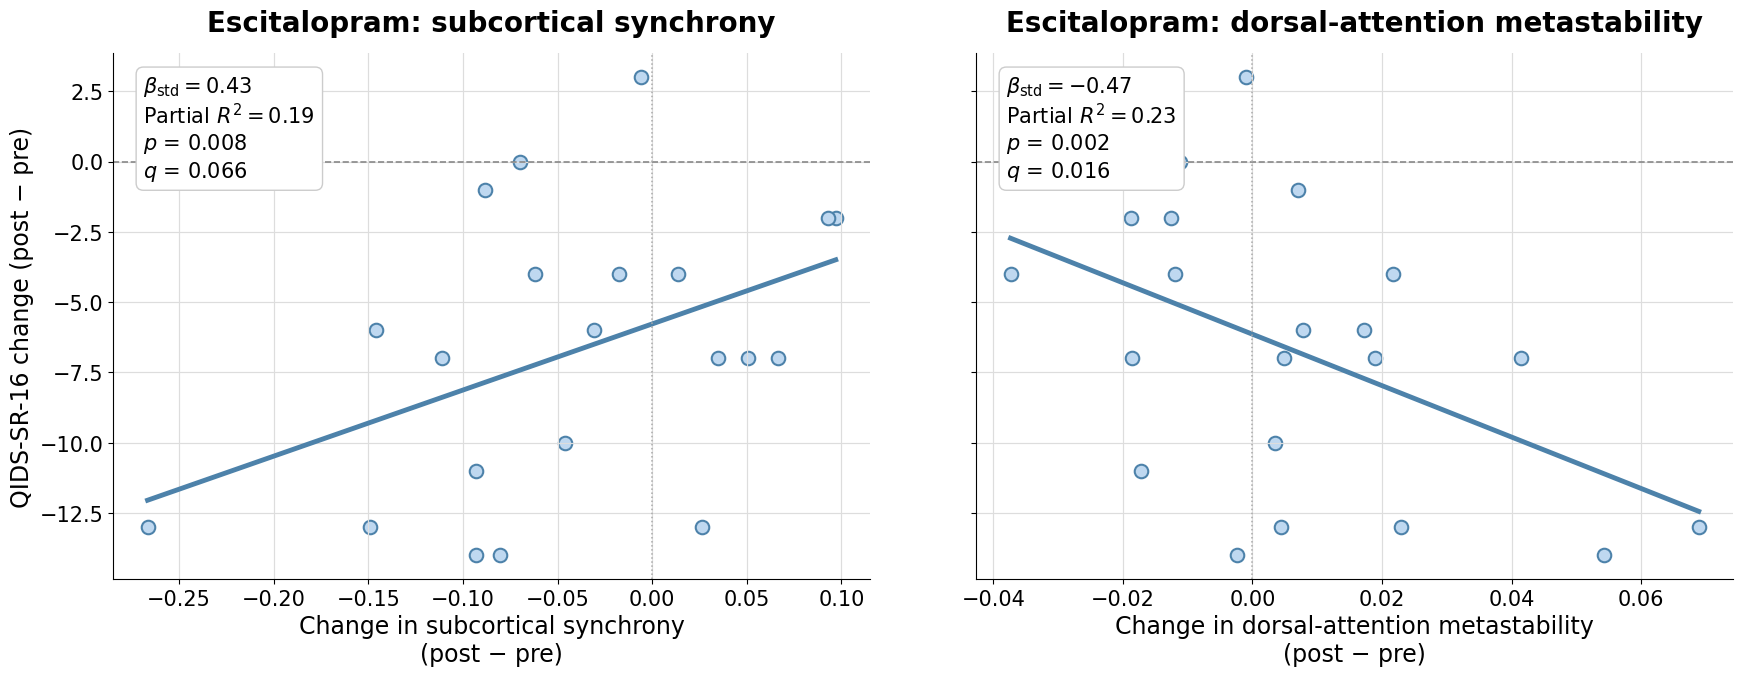

In [55]:
plot_models = [
    ("escitalopram", "synchrony", "Subcortex", "Escitalopram: subcortical synchrony",
     "Change in subcortical synchrony\n(post − pre)"),
    ("escitalopram", "metastability", "Dorsal attention",
     "Escitalopram: dorsal-attention metastability",
     "Change in dorsal-attention metastability\n(post − pre)"),
]

fig, axes = plt.subplots(1, 2, figsize=(18, 7.2), sharey=True, facecolor="white")
for ax, (treatment, metric, spatial_set, title, x_label) in zip(axes, plot_models):
    data = phase_qids_regression_data.loc[
        (phase_qids_regression_data["treatment"] == treatment)
        & (phase_qids_regression_data["metric"] == metric)
        & (phase_qids_regression_data["spatial_set"] == spatial_set)
    ].dropna(subset=["brain_change", "qids_change", "qids_pre"])
    result = phase_qids_regressions.loc[
        (phase_qids_regressions["treatment"] == treatment)
        & (phase_qids_regressions["metric"] == metric)
        & (phase_qids_regressions["spatial_set"] == spatial_set)
    ].iloc[0]

    x = data["brain_change"].to_numpy()
    ax.scatter(x, data["qids_change"], s=95, facecolor="#BFD8F0", edgecolor="#4D82AA", linewidth=1.5)
    x_line = np.linspace(x.min(), x.max(), 300)
    y_line = (
        result["intercept"]
        + result["beta_qids_pre"] * result["mean_qids_pre"]
        + result["beta_brain_change"] * x_line
    )
    ax.plot(x_line, y_line, color="#4D82AA", linewidth=3.5)
    p_text = "< .001" if result["p_raw"] < 0.001 else f"= {result['p_raw']:.3f}"
    q_text = "< .001" if result["p_fdr"] < 0.001 else f"= {result['p_fdr']:.3f}"
    ax.text(
        0.04, 0.96,
        rf"$\beta_{{\mathrm{{std}}}} = {result['standardised_beta']:.2f}$" + "\n"
        + rf"Partial $R^2 = {result['partial_r2']:.2f}$" + "\n"
        + rf"$p$ {p_text}" + "\n" + rf"$q$ {q_text}",
        transform=ax.transAxes, ha="left", va="top", fontsize=15,
        bbox={"boxstyle": "round,pad=0.35", "facecolor": "white", "edgecolor": "#CCCCCC"},
    )
    ax.axhline(0, color="#888888", linestyle="--", linewidth=1.2)
    ax.axvline(0, color="#AAAAAA", linestyle=":", linewidth=1.1)
    ax.set_xlabel(x_label, fontsize=17)
    ax.set_title(title, fontsize=20, fontweight="bold", pad=16)
    ax.grid(color="#DDDDDD", linewidth=0.85)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(labelsize=15)

axes[0].set_ylabel("QIDS-SR-16 change (post − pre)", fontsize=17)
fig.subplots_adjust(left=0.085, right=0.985, top=0.91, bottom=0.18, wspace=0.14)
plt.show()


### Baseline-adjusted regression table


In [56]:
regression_table = phase_qids_regressions.copy()
regression_table["Treatment"] = regression_table["treatment"].map({
    "escitalopram": "Escitalopram", "psilocybin": "Psilocybin"
})
regression_table["Metric"] = regression_table["metric"].str.capitalize()
regression_table["Spatial region"] = regression_table["spatial_set"].map(
    lambda x: spatial_display.get(x, x)
)
regression_table["Standardised β 95% HC3 CI"] = regression_table.apply(
    lambda row: f"[{row['standardised_ci_low']:.3f}, {row['standardised_ci_high']:.3f}]", axis=1
)
regression_table["Raw β 95% HC3 CI"] = regression_table.apply(
    lambda row: f"[{row['brain_change_ci_low']:.3f}, {row['brain_change_ci_high']:.3f}]", axis=1
)
regression_table["spatial_order"] = regression_table["spatial_set"].map(
    {name: index for index, name in enumerate(spatial_order)}
)
regression_table["treatment_order"] = regression_table["treatment"].map(
    {"escitalopram": 0, "psilocybin": 1}
)
regression_table["metric_order"] = regression_table["metric"].map(
    {"synchrony": 0, "metastability": 1}
)
regression_table = regression_table.sort_values(
    ["treatment_order", "metric_order", "spatial_order"]
)
regression_table = regression_table[
    [
        "Treatment", "Metric", "Spatial region", "n", "standardised_beta",
        "Standardised β 95% HC3 CI", "beta_brain_change", "brain_change_hc3_se",
        "Raw β 95% HC3 CI", "beta_qids_pre", "p_qids_pre", "partial_r2",
        "adjusted_r2", "p_raw", "p_fdr", "max_cooks_subject", "max_cooks_d",
        "n_cooks_above_threshold",
    ]
].rename(columns={
    "n": "N", "standardised_beta": "Standardised β", "beta_brain_change": "Raw β",
    "brain_change_hc3_se": "HC3 SE", "beta_qids_pre": "Baseline-QIDS β",
    "p_qids_pre": "Baseline-QIDS p", "partial_r2": "Partial R²",
    "adjusted_r2": "Adjusted R²", "p_raw": "Raw p", "p_fdr": "BH-FDR q",
    "max_cooks_subject": "Participant with maximum Cook's D",
    "max_cooks_d": "Maximum Cook's D",
    "n_cooks_above_threshold": "N above Cook's threshold",
})

display(regression_table.reset_index(drop=True).style.format({
    "Standardised β": "{:.3f}", "Raw β": "{:.3f}", "HC3 SE": "{:.3f}",
    "Baseline-QIDS β": "{:.3f}", "Baseline-QIDS p": "{:.4f}",
    "Partial R²": "{:.3f}", "Adjusted R²": "{:.3f}", "Raw p": "{:.4f}",
    "BH-FDR q": "{:.4f}", "Maximum Cook's D": "{:.3f}",
}, na_rep="—"))


,Treatment,Metric,Spatial region,N,Standardised β,Standardised β 95% HC3 CI,Raw β,HC3 SE,Raw β 95% HC3 CI,Baseline-QIDS β,Baseline-QIDS p,Partial R²,Adjusted R²,Raw p,BH-FDR q,Participant with maximum Cook's D,Maximum Cook's D,N above Cook's threshold
0,Escitalopram,Synchrony,Whole brain,21,0.294,"[-0.112, 0.700]",15.288,10.043,"[-5.812, 36.387]",-0.229,0.3168,0.088,0.021,0.1453,—,18,0.236,1
1,Escitalopram,Synchrony,Visual,21,-0.051,"[-0.818, 0.716]",-4.126,29.541,"[-66.189, 57.938]",-0.190,0.4655,0.003,-0.072,0.8905,0.9787,20,0.550,3
2,Escitalopram,Synchrony,Somatomotor,21,-0.112,"[-0.684, 0.459]",-9.755,23.613,"[-59.364, 39.854]",-0.203,0.4279,0.013,-0.060,0.6844,0.9125,30,0.243,3
3,Escitalopram,Synchrony,Dorsal attention,21,0.195,"[-0.350, 0.740]",14.261,18.978,"[-25.610, 54.131]",-0.218,0.3859,0.039,-0.033,0.4621,0.9125,18,0.256,2
4,Escitalopram,Synchrony,Salience / ventral attention,21,0.105,"[-0.425, 0.635]",7.675,18.417,"[-31.019, 46.368]",-0.203,0.4043,0.011,-0.062,0.6818,0.9125,18,0.222,1
5,Escitalopram,Synchrony,Limbic,21,0.006,"[-0.487, 0.500]",0.484,17.885,"[-37.090, 38.059]",-0.196,0.4393,0.000,-0.074,0.9787,0.9787,18,0.228,1
6,Escitalopram,Synchrony,Frontoparietal control,21,0.271,"[-0.175, 0.717]",17.070,13.364,"[-11.006, 45.147]",-0.299,0.2479,0.067,-0.003,0.2177,0.5806,18,0.239,1
7,Escitalopram,Synchrony,Default mode,21,0.284,"[-0.135, 0.702]",19.864,13.948,"[-9.439, 49.167]",-0.219,0.3914,0.083,0.015,0.1715,0.5806,18,0.241,1
8,Escitalopram,Synchrony,Subcortex,21,0.425,"[0.124, 0.726]",23.518,7.917,"[6.885, 40.151]",-0.204,0.3420,0.187,0.126,0.0082,0.0655,18,0.249,1
9,Escitalopram,Metastability,Whole brain,21,-0.100,"[-0.648, 0.449]",-37.220,97.308,"[-241.657, 167.217]",-0.185,0.4691,0.010,-0.063,0.7066,—,18,0.348,1


### Regression diagnostics for the two raw-significant models


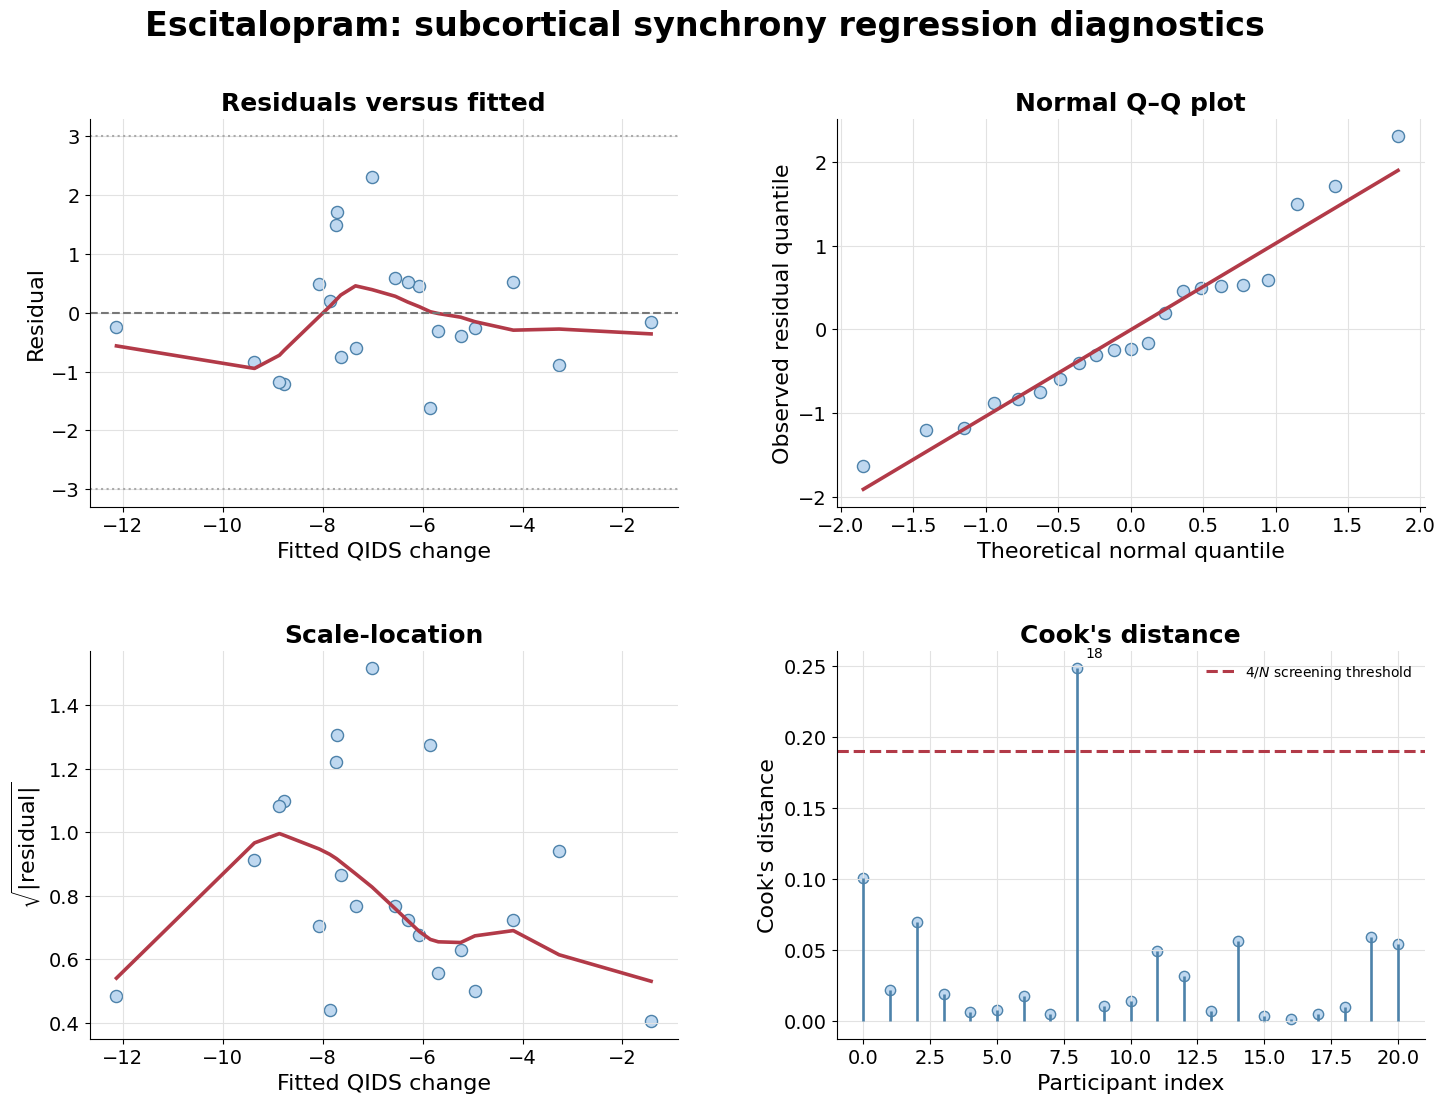

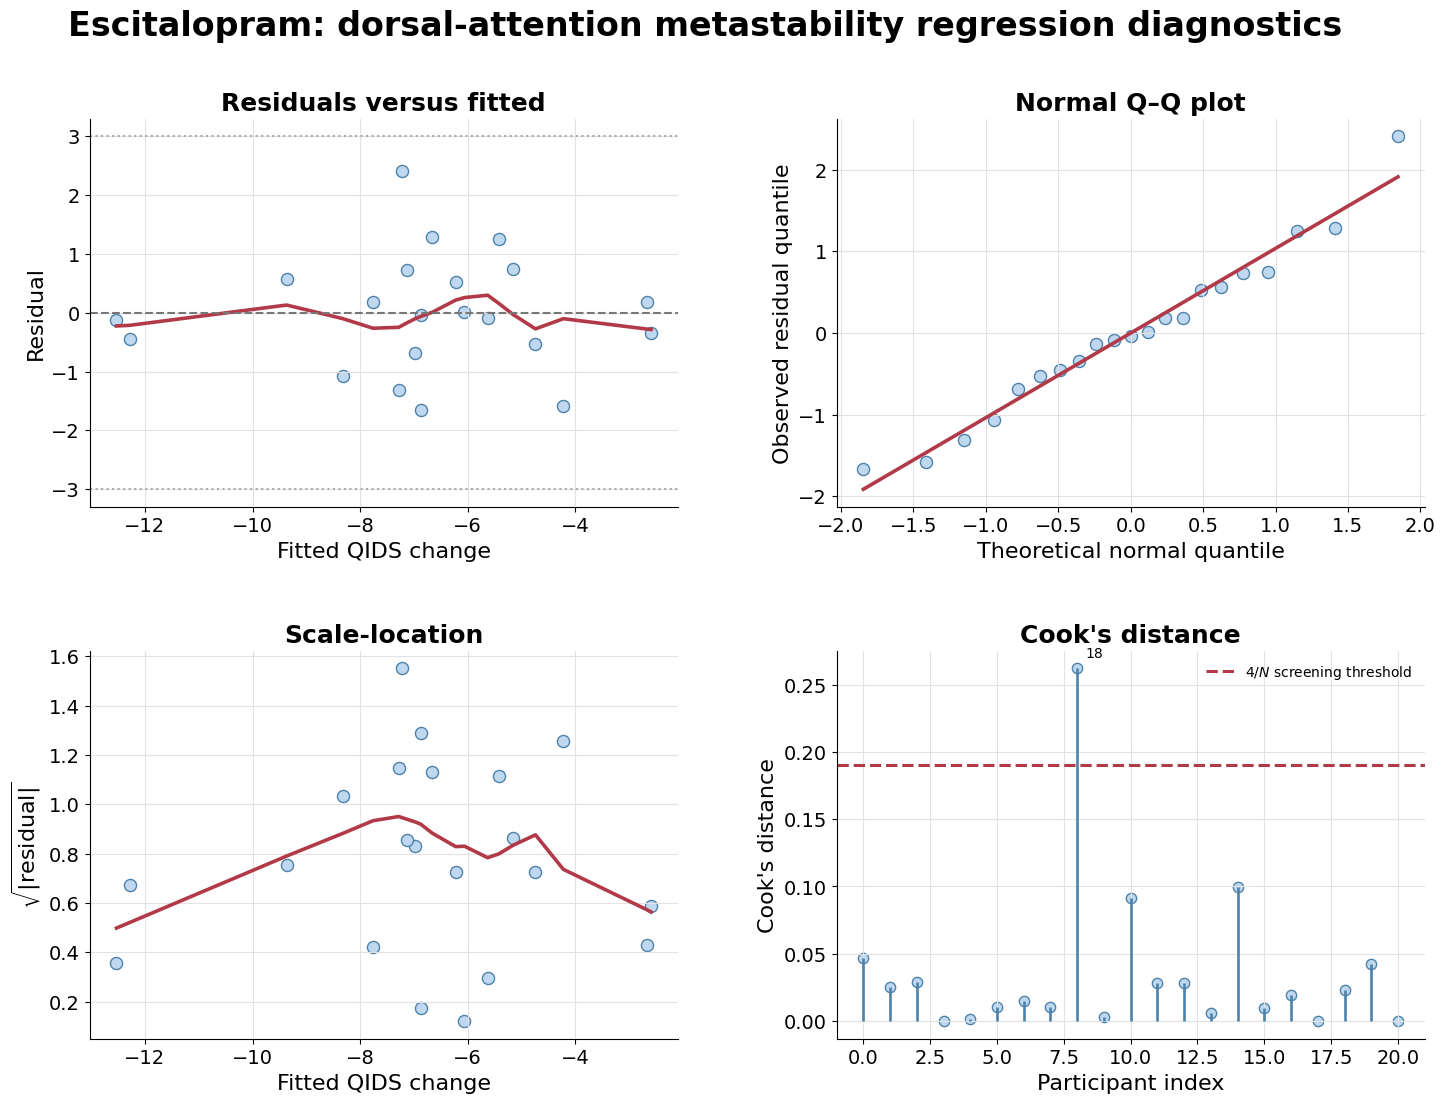

In [57]:
for treatment, metric, spatial_set, title, _ in plot_models:
    model, model_data = regression_models[(treatment, metric, spatial_set)]
    influence = model.get_influence()
    fitted = model.fittedvalues.to_numpy()
    residuals = influence.resid_studentized_internal
    cooks_distance = influence.cooks_distance[0]

    fig, axes = plt.subplots(2, 2, figsize=(15, 11.5), facecolor="white")
    axes = axes.ravel()

    axes[0].scatter(fitted, residuals, s=76, facecolor="#BFD8F0", edgecolor="#4D82AA")
    smooth = lowess(residuals, fitted, frac=0.70, return_sorted=True)
    axes[0].plot(smooth[:, 0], smooth[:, 1], color="#B23A48", linewidth=2.6)
    axes[0].axhline(0, color="#777777", linestyle="--")
    axes[0].axhline(3, color="#AAAAAA", linestyle=":")
    axes[0].axhline(-3, color="#AAAAAA", linestyle=":")
    axes[0].set(title="Residuals versus fitted", xlabel="Fitted QIDS change", ylabel="Residual")

    (theoretical, ordered), (slope, intercept, _) = stats.probplot(residuals, dist="norm")
    axes[1].scatter(theoretical, ordered, s=76, facecolor="#BFD8F0", edgecolor="#4D82AA")
    qq_x = np.array([theoretical.min(), theoretical.max()])
    axes[1].plot(qq_x, intercept + slope * qq_x, color="#B23A48", linewidth=2.6)
    axes[1].set(title="Normal Q–Q plot", xlabel="Theoretical normal quantile", ylabel="Observed residual quantile")

    scale_location = np.sqrt(np.abs(residuals))
    axes[2].scatter(fitted, scale_location, s=76, facecolor="#BFD8F0", edgecolor="#4D82AA")
    smooth = lowess(scale_location, fitted, frac=0.70, return_sorted=True)
    axes[2].plot(smooth[:, 0], smooth[:, 1], color="#B23A48", linewidth=2.6)
    axes[2].set(title="Scale-location", xlabel="Fitted QIDS change", ylabel=r"$\sqrt{|\mathrm{residual}|}$")

    positions = np.arange(len(cooks_distance))
    axes[3].vlines(positions, 0, cooks_distance, color="#4D82AA", linewidth=1.9)
    axes[3].scatter(positions, cooks_distance, s=55, facecolor="#BFD8F0", edgecolor="#4D82AA")
    axes[3].axhline(4 / len(model_data), color="#B23A48", linestyle="--", linewidth=2.2, label=r"$4/N$ screening threshold")
    index = int(np.argmax(cooks_distance))
    axes[3].annotate(str(model_data.loc[index, "subjects"]), (index, cooks_distance[index]), xytext=(6, 8), textcoords="offset points")
    axes[3].set(title="Cook's distance", xlabel="Participant index", ylabel="Cook's distance")
    axes[3].legend(frameon=False)

    for ax in axes:
        ax.grid(color="#E2E2E2", linewidth=0.8)
        ax.spines[["top", "right"]].set_visible(False)
        ax.tick_params(labelsize=14)
        ax.title.set_fontsize(18)
        ax.title.set_fontweight("bold")
        ax.xaxis.label.set_size(16)
        ax.yaxis.label.set_size(16)

    fig.suptitle(f"{title} regression diagnostics", fontsize=24, fontweight="bold", y=0.975)
    fig.subplots_adjust(left=0.09, right=0.98, top=0.88, bottom=0.08, wspace=0.27, hspace=0.37)
    plt.show()
